# 📝 Week 3: Peringkasan Teks Bahasa Indonesia (Text Summarization)

Notebook ini mendemonstrasikan teknik **peringkasan teks otomatis** menggunakan metode **TF-IDF** pada teks berbahasa Indonesia dengan **Sastrawi** untuk penghapusan stopword.

## 📚 Tujuan Pembelajaran

1. Memahami konsep peringkasan teks (text summarization) berbasis ekstraktif
2. Melakukan tokenisasi kalimat menggunakan NLTK
3. Menghapus stopword bahasa Indonesia menggunakan Sastrawi
4. Menerapkan TF-IDF untuk menghitung bobot kata dalam kalimat
5. Menghitung skor kalimat dan menentukan threshold
6. Menghasilkan ringkasan dari teks asli
7. Memahami perhitungan manual TF-IDF

## 1) Import Library

In [1]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import pandas as pd
import math

nltk.download('punkt_tab', quiet=True)

print('✅ Semua library berhasil di-import!')

✅ Semua library berhasil di-import!


## 2) Definisi Dokumen

Dokumen yang digunakan adalah artikel berita berbahasa Indonesia tentang **Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara)** dan kerja sama investasi Indonesia-Qatar.

In [2]:
document = """Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.

Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.

Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.

\"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini,\" kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.

Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. Buka peluang investasi sektor strategis
Dana tersebut akan difokuskan pada peluang investasi di berbagai sektor strategis, antara lain hilirisasi, kesehatan, energi terbarukan, teknologi, serta sektor-sektor lain yang dipandang relevan oleh pengelola dana.

\"Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional,\" ujar Rosan.

Lebih lanjut, Rosan menegaskan, kolaborasi ini menjadi bukti kepercayaan dunia internasional terhadap kapasitas kelembagaan Indonesia dalam mengelola investasi berskala besar.

\"Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar. Ini menunjukkan bahwa Indonesia tidak hanya menjadi tujuan investasi, tetapi juga memiliki kapasitas kelembagaan yang mumpuni untuk mengelola investasi secara profesional dan akuntabel,\" ungkapnya.

Inisiatif co-partnership dan perluasan kerja sama strategis ini diharapkan tidak hanya memperkuat hubungan diplomatik kedua negara, tetapi juga memberikan kontribusi nyata terhadap percepatan pembangunan ekonomi dan peningkatan kesejahteraan masyarakat Indonesia."""

print('📌 DOKUMEN ASLI:')
print('=' * 80)
print(document.strip())
print('=' * 80)
print(f'📊 Panjang dokumen: {len(document.split())} kata')

📌 DOKUMEN ASLI:
Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.

Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.

Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.

"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 

## 3) Tokenisasi Kalimat

Dokumen akan dipecah menjadi kalimat-kalimat menggunakan `sent_tokenize` dari NLTK.

In [3]:
sent_tokens = sent_tokenize(document)

print('📌 HASIL TOKENISASI KALIMAT:')
print('=' * 80)
for i, sent in enumerate(sent_tokens):
    print(f'  Kalimat {i + 1}: {sent}')
    print('-' * 80)
print(f'\n📊 Jumlah kalimat: {len(sent_tokens)}')

📌 HASIL TOKENISASI KALIMAT:
  Kalimat 1: Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
--------------------------------------------------------------------------------
  Kalimat 2: Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
--------------------------------------------------------------------------------
  Kalimat 3: Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.
--------------------------------------------------------------------------------
  Kalimat 4: Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
--------------------------------------------------------------------------------
  Ka

## 4) Hapus Stopword dengan Sastrawi

Stopword bahasa Indonesia akan dihapus menggunakan library **Sastrawi** agar TF-IDF lebih fokus pada kata-kata bermakna.

In [4]:
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_tokens]

print('📌 KALIMAT SETELAH HAPUS STOPWORD:')
print('=' * 80)
for i, (original, cleaned) in enumerate(zip(sent_tokens, cleaned_sentences)):
    print(f'  Kalimat {i + 1}:')
    print(f'    🔹 Asli    : {original[:100]}...')
    print(f'    🔹 Bersih  : {cleaned[:100]}...')
    print('-' * 80)

print(f'\n✅ Stopword berhasil dihapus dari {len(cleaned_sentences)} kalimat')

📌 KALIMAT SETELAH HAPUS STOPWORD:
  Kalimat 1:
    🔹 Asli    : Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi in...
    🔹 Bersih  : Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi in...
--------------------------------------------------------------------------------
  Kalimat 2:
    🔹 Asli    : Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto...
    🔹 Bersih  : Kesepakatan Indonesia Qatar merupakan buah kunjungan resmi Presiden Prabowo Subianto Doha....
--------------------------------------------------------------------------------
  Kalimat 3:
    🔹 Asli    : Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan str...
    🔹 Bersih  : Pemerintah Republik Indonesia Pemerintah Qatar menggelar diskusi menyepakati kemitraan strategis (co...
-------------------------------------------------------

## 5) Vektorisasi TF-IDF

Setiap kalimat yang sudah bersih akan diubah menjadi vektor TF-IDF.

In [5]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(cleaned_sentences)

feature_names = vectorizer.get_feature_names_out()

print('✅ TF-IDF Vectorizer berhasil dilatih!')
print(f'📊 Ukuran matriks TF-IDF: {tfidf_matrix.shape}')
print(f'   - Jumlah kalimat : {tfidf_matrix.shape[0]}')
print(f'   - Jumlah kata unik: {tfidf_matrix.shape[1]}')

print('\n📌 Contoh fitur (kata) dalam vocabulary:')
print(feature_names[:20])

✅ TF-IDF Vectorizer berhasil dilatih!
📊 Ukuran matriks TF-IDF: (15, 163)
   - Jumlah kalimat : 15
   - Jumlah kata unik: 163

📌 Contoh fitur (kata) dalam vocabulary:
['15' '2025' 'adalah' 'akan' 'akuntabel' 'anagata' 'antaranya' 'april'
 'authority' 'badan' 'baik' 'berbagai' 'berfokus' 'berkelanjutan'
 'berkontribusi' 'berorientasi' 'bersama' 'berskala' 'besar' 'bpi']


📌 NILAI TF-IDF KALIMAT PERTAMA (setelah hapus stopword):
      Kata   TF-IDF
 investasi 0.301340
     badan 0.274034
   anagata 0.274034
disepakati 0.274034
      daya 0.274034
  mengawal 0.274034
   jakarta 0.274034
     telah 0.274034
 realisasi 0.274034
 nusantara 0.274034
       bpi 0.237952
      siap 0.237952
 pengelola 0.237952
 danantara 0.192495
     qatar 0.162553


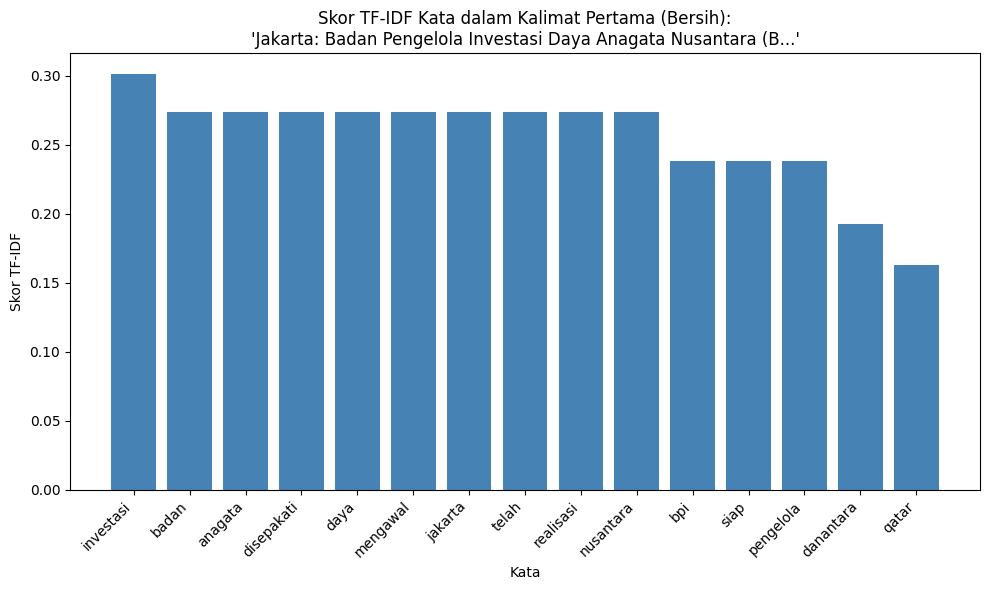

In [6]:
# Menampilkan TF-IDF untuk kalimat pertama
def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
    """Mengembalikan DataFrame TF-IDF untuk kalimat tertentu."""
    values = tfidf_matrix[sentence_index].toarray().flatten()
    df = pd.DataFrame({'Kata': feature_names, 'TF-IDF': values})
    df = df[df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
    return df

df_first = get_tfidf_for_sentence(tfidf_matrix, 0, feature_names)

print('📌 NILAI TF-IDF KALIMAT PERTAMA (setelah hapus stopword):')
print('=' * 80)
print(df_first.to_string(index=False))

# Visualisasi
plt.figure(figsize=(10, 6))
plt.bar(df_first['Kata'], df_first['TF-IDF'], color='steelblue')
plt.xlabel('Kata')
plt.ylabel('Skor TF-IDF')
plt.title(f"Skor TF-IDF Kata dalam Kalimat Pertama (Bersih):\n'{cleaned_sentences[0][:60]}...'")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# Tampilkan matriks TF-IDF lengkap untuk semua kalimat
df_all = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
df_all.index = [f'Kalimat {i + 1}' for i in range(len(sent_tokens))]

print('📌 NILAI TF-IDF SEMUA KALIMAT:')
print('=' * 80)

for i in range(len(sent_tokens)):
    df_sent = df_all.iloc[i]
    df_sent = df_sent[df_sent > 0].sort_values(ascending=False)
    print(f'\n  🔹 Kalimat {i + 1}: {sent_tokens[i][:80]}...')
    print(df_sent.to_string())
    print('-' * 80)

📌 NILAI TF-IDF SEMUA KALIMAT:

  🔹 Kalimat 1: Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap m...
investasi     0.301340
badan         0.274034
anagata       0.274034
disepakati    0.274034
daya          0.274034
mengawal      0.274034
jakarta       0.274034
telah         0.274034
realisasi     0.274034
nusantara     0.274034
bpi           0.237952
siap          0.237952
pengelola     0.237952
danantara     0.192495
qatar         0.162553
--------------------------------------------------------------------------------

  🔹 Kalimat 2: Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presi...
buah           0.340412
doha           0.340412
kesepakatan    0.340412
resmi          0.340412
subianto       0.340412
prabowo        0.295591
kunjungan      0.295591
presiden       0.295591
merupakan      0.295591
qatar          0.201927
indonesia      0.174146
--------------------------------------------------------------------------------

## 6) Hitung Skor Kalimat

Skor setiap kalimat dihitung dari **rata-rata nilai TF-IDF** kata-kata yang ada di dalamnya.

📌 SKOR RATA-RATA TF-IDF SETIAP KALIMAT:
  Kalimat 1:
    🔹 Jumlah TF-IDF  : 3.8366
    🔹 Jumlah kata     : 15
    🔹 Skor rata-rata  : 0.2558
--------------------------------------------------------------------------------
  Kalimat 2:
    🔹 Jumlah TF-IDF  : 3.2605
    🔹 Jumlah kata     : 11
    🔹 Skor rata-rata  : 0.2964
--------------------------------------------------------------------------------
  Kalimat 3:
    🔹 Jumlah TF-IDF  : 4.1842
    🔹 Jumlah kata     : 19
    🔹 Skor rata-rata  : 0.2202
--------------------------------------------------------------------------------
  Kalimat 4:
    🔹 Jumlah TF-IDF  : 3.6796
    🔹 Jumlah kata     : 14
    🔹 Skor rata-rata  : 0.2628
--------------------------------------------------------------------------------
  Kalimat 5:
    🔹 Jumlah TF-IDF  : 4.0636
    🔹 Jumlah kata     : 17
    🔹 Skor rata-rata  : 0.2390
--------------------------------------------------------------------------------
  Kalimat 6:
    🔹 Jumlah TF-IDF  : 4.9252
    🔹 J

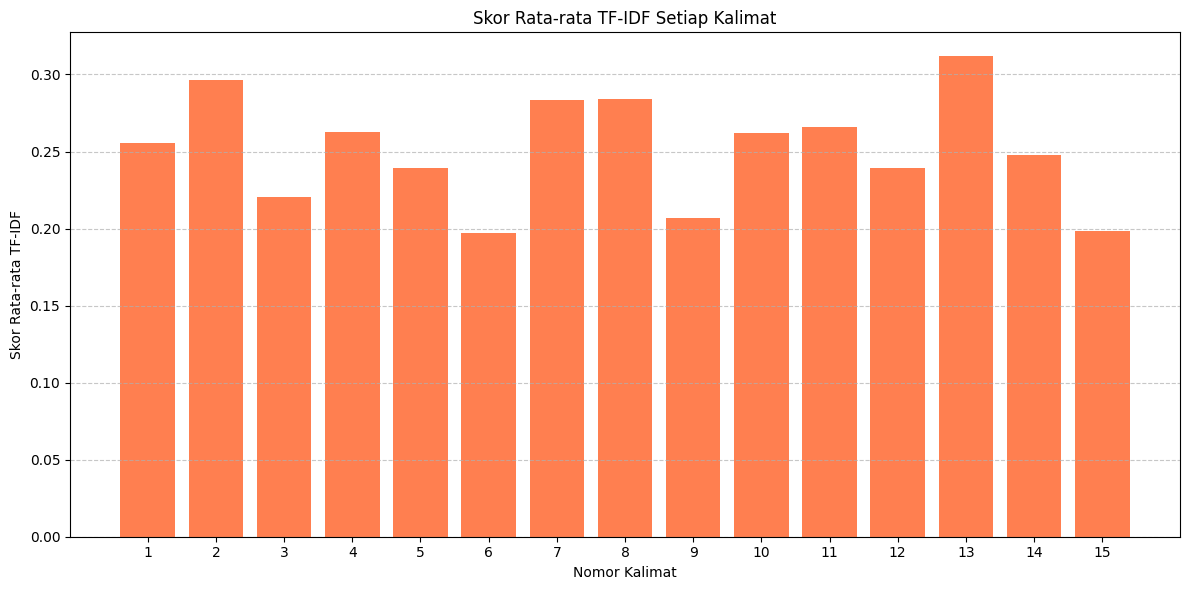


📌 PENJELASAN HISTOGRAM:
  - Bar yang lebih tinggi = kalimat mengandung kata yang lebih penting dan unik dalam artikel
  - Bar yang lebih rendah = kalimat mengandung kata yang lebih umum di seluruh artikel
  - Dengan melihat histogram, kita bisa mengetahui kalimat mana yang paling informatif


In [7]:
sent_scores = []

print('📌 SKOR RATA-RATA TF-IDF SETIAP KALIMAT:')
print('=' * 80)

for idx, row in enumerate(tfidf_matrix):
    total_score = row.sum()
    num_words = len(row.data)
    avg_score = total_score / num_words if num_words > 0 else 0
    sent_scores.append(avg_score)
    print(f'  Kalimat {idx + 1}:')
    print(f'    🔹 Jumlah TF-IDF  : {total_score:.4f}')
    print(f'    🔹 Jumlah kata     : {num_words}')
    print(f'    🔹 Skor rata-rata  : {avg_score:.4f}')
    print('-' * 80)

# Visualisasi skor kalimat
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores, color='coral')
plt.xlabel('Nomor Kalimat')
plt.ylabel('Skor Rata-rata TF-IDF')
plt.title('Skor Rata-rata TF-IDF Setiap Kalimat')
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('\n📌 PENJELASAN HISTOGRAM:')
print('  - Bar yang lebih tinggi = kalimat mengandung kata yang lebih penting dan unik dalam artikel')
print('  - Bar yang lebih rendah = kalimat mengandung kata yang lebih umum di seluruh artikel')
print('  - Dengan melihat histogram, kita bisa mengetahui kalimat mana yang paling informatif')

## 7) Tentukan Threshold & Buat Ringkasan

Threshold dihitung dari rata-rata seluruh skor kalimat. Kalimat yang skornya di atas threshold akan masuk ke ringkasan.

In [8]:
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print(f'📌 THRESHOLD (Rata-rata Skor Kalimat): {threshold:.4f}')
print('=' * 80)

# Pilih kalimat yang skornya di atas threshold
summary_sentences = []
print('\n📌 KALIMAT YANG LOLOS THRESHOLD:')
print('-' * 80)
for idx, (score, sent) in enumerate(zip(sent_scores, sent_tokens)):
    if score >= threshold:
        summary_sentences.append(sent)
        print(f'  ✅ Kalimat {idx + 1} (skor: {score:.4f}): {sent[:80]}...')

print('\n' + '=' * 80)
print('📌 HASIL RINGKASAN:')
print('=' * 80)
summary = ' '.join(summary_sentences)
print(summary)
print('=' * 80)
print(f'\n📊 Jumlah kalimat asli    : {len(sent_tokens)}')
print(f'📊 Jumlah kalimat ringkasan: {len(summary_sentences)}')
print(f'📊 Rasio kompresi          : {len(summary_sentences)/len(sent_tokens)*100:.1f}%')

📌 THRESHOLD (Rata-rata Skor Kalimat): 0.2513

📌 KALIMAT YANG LOLOS THRESHOLD:
--------------------------------------------------------------------------------
  ✅ Kalimat 1 (skor: 0.2558): Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap m...
  ✅ Kalimat 2 (skor: 0.2964): Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presi...
  ✅ Kalimat 4 (skor: 0.2628): Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana inves...
  ✅ Kalimat 7 (skor: 0.2837): Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar US...
  ✅ Kalimat 8 (skor: 0.2838): Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Author...
  ✅ Kalimat 10 (skor: 0.2621): "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kel...
  ✅ Kalimat 11 (skor: 0.2656): Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak ...
  ✅ Kalimat 13 (skor: 0.3118): "Kemitraan

## 8) Perhitungan Manual TF-IDF

Pada bagian ini, kita akan menghitung **TF-IDF secara manual** untuk kata **"dana"** di setiap kalimat, untuk memahami cara kerja TF-IDF secara lebih mendalam.

In [12]:
# Fungsi untuk menghitung TF (Term Frequency)
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Fungsi untuk menghitung IDF (Inverse Document Frequency)
def calculate_idf(term, all_documents):
    num_docs_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_docs_with_term > 0:
        return math.log(len(all_documents) / num_docs_with_term)
    else:
        return 0

# Hitung TF-IDF manual untuk kata "dana"
target_word = 'dana'

print(f'📌 PERHITUNGAN MANUAL TF-IDF UNTUK KATA "{target_word}":')
print('=' * 80)

tfidf_scores = {}
for i, sent in enumerate(sent_tokens):
    cleaned = stopword_remover.remove(sent)
    tf = calculate_tf(target_word, cleaned)
    idf = calculate_idf(target_word, cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f'Kalimat {i + 1}'] = tfidf
    if tfidf > 0:
        print(f'  🔹 Kalimat {i + 1}: TF={tf:.4f} × IDF={idf:.4f} = TF-IDF={tfidf:.4f}')

# IDF keseluruhan
overall_idf = calculate_idf(target_word, cleaned_sentences)
print(f'\n📊 IDF keseluruhan untuk "{target_word}": {overall_idf:.4f}')

print('\n📌 SEMUA SKOR TF-IDF:')
print('-' * 80)
for sent_num, score in tfidf_scores.items():
    print(f'  {sent_num}: {score:.4f}')

📌 PERHITUNGAN MANUAL TF-IDF UNTUK KATA "dana":
  🔹 Kalimat 3: TF=0.0435 × IDF=0.7621 = TF-IDF=0.0331
  🔹 Kalimat 4: TF=0.0667 × IDF=0.7621 = TF-IDF=0.0508
  🔹 Kalimat 5: TF=0.0500 × IDF=0.7621 = TF-IDF=0.0381
  🔹 Kalimat 6: TF=0.0323 × IDF=0.7621 = TF-IDF=0.0246
  🔹 Kalimat 7: TF=0.0833 × IDF=0.7621 = TF-IDF=0.0635
  🔹 Kalimat 8: TF=0.0714 × IDF=0.7621 = TF-IDF=0.0544
  🔹 Kalimat 9: TF=0.0645 × IDF=0.7621 = TF-IDF=0.0492

📊 IDF keseluruhan untuk "dana": 0.7621

📌 SEMUA SKOR TF-IDF:
--------------------------------------------------------------------------------
  Kalimat 1: 0.0000
  Kalimat 2: 0.0000
  Kalimat 3: 0.0331
  Kalimat 4: 0.0508
  Kalimat 5: 0.0381
  Kalimat 6: 0.0246
  Kalimat 7: 0.0635
  Kalimat 8: 0.0544
  Kalimat 9: 0.0492
  Kalimat 10: 0.0000
  Kalimat 11: 0.0000
  Kalimat 12: 0.0000
  Kalimat 13: 0.0000
  Kalimat 14: 0.0000
  Kalimat 15: 0.0000


## ✅ Kesimpulan

Pada notebook ini, kita telah berhasil:
1. Melakukan **tokenisasi kalimat** pada teks berbahasa Indonesia
2. Menghapus **stopword** menggunakan **Sastrawi** untuk bahasa Indonesia
3. Menerapkan **TF-IDF** untuk menghitung bobot kata dalam kalimat
4. Menghitung **skor kalimat** berdasarkan rata-rata TF-IDF dan memvisualisasikannya
5. Menentukan **threshold** dan menghasilkan **ringkasan** otomatis
6. Memahami **perhitungan manual TF-IDF** untuk kata tertentu

Perbedaan utama dengan teks Inggris adalah penggunaan **Sastrawi** untuk menghapus stopword bahasa Indonesia, karena `TfidfVectorizer` hanya menyediakan daftar stopword untuk bahasa Inggris.